<a href="https://colab.research.google.com/github/symnll/DeepLearning/blob/main/DLComput.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle

In [ ]:
train_dir = '/content/drive/MyDrive/Colab Notebooks/Training/'
test_dir = '/content/drive/MyDrive/Colab Notebooks/Testing/'

train_paths = []
train_labels = []
for label in os.listdir(train_dir):
  for image in os.listdir(os.path.join(train_dir, label)):
    train_paths.append(os.path.join(train_dir, label, image))
    train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

test_paths = []
test_labels = []
for label in os.listdir(test_dir):
  for image in os.listdir(os.path.join(test_dir, label)):
    test_paths.append(os.path.join(test_dir, label, image))
    test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

<function matplotlib.pyplot.show(close=None, block=None)>

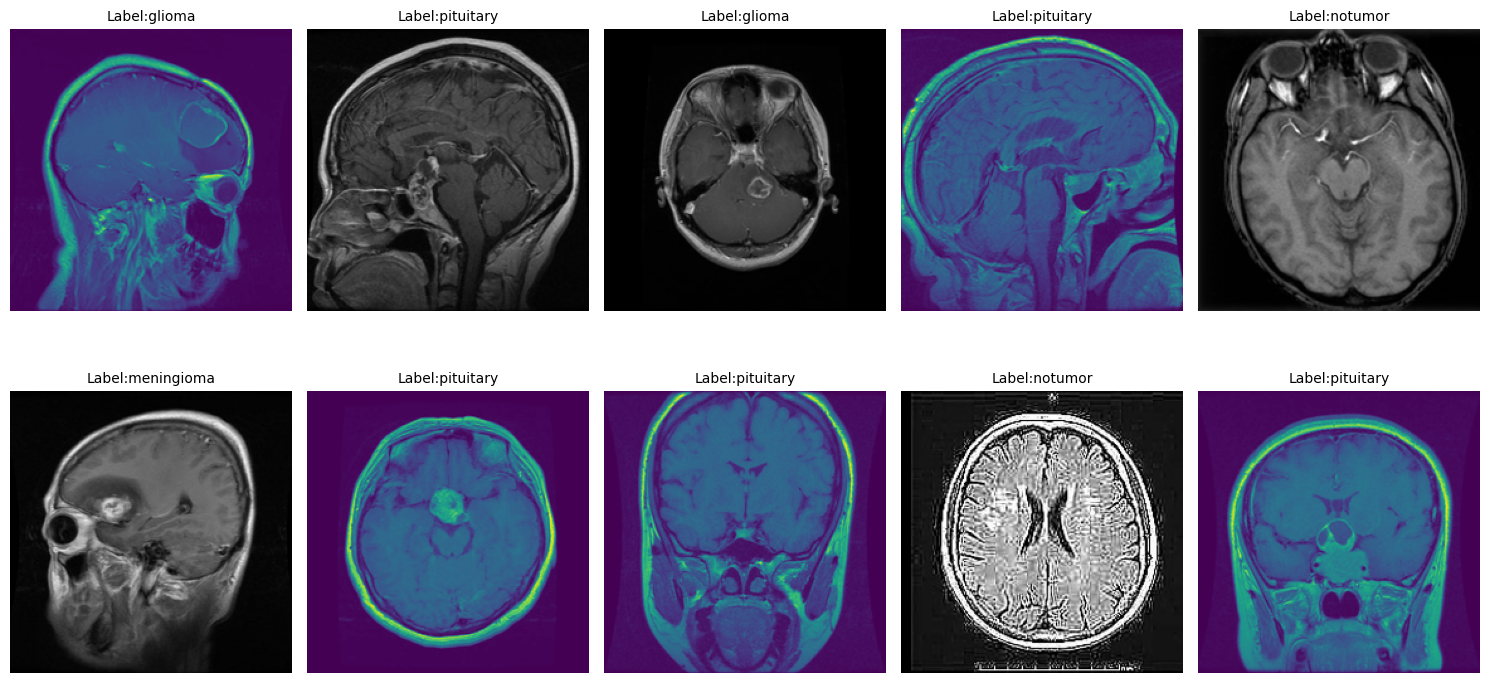

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

random_indices = random.sample(range(len(train_paths)),10)

fig, axes = plt.subplots(2, 5, figsize=(15,8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
  img_path = train_paths[idx]
  img = Image.open(img_path)
  img = img.resize((224, 224))

  axes[i].imshow(img)
  axes[i].axis('off')
  axes[i].set_title(f"Label:{train_labels[idx]}", fontsize = 10)

plt.tight_layout()
plt.show

In [ ]:
import numpy as np
import random
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img
import os

def augment_image(image):
  image = Image.fromarray(np.uint8(image))
  image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
  image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
  image = np.array(image)/ 255.0
  return image

def open_images(paths):
  images = []
  for path in paths:
    image = load_img(path, target_size = (IMAGE_SIZE, IMAGE_SIZE))
    image = augment_image(image)
    images.append(image)
  return np.array(images)

def encode_label(labels):
  unique_labels = os.listdir(train_dir)
  encoded = [unique_labels.index(label) for label in labels]
  return np.array(encoded)

def datgen(paths, labels, batch_size = 12, epochs = 1):
  for _ in range(epochs):
    for i in range(0, len(paths), batch_size):
      batch_paths = paths[i:i + batch_size ]
      batch_images = open_images(batch_paths)
      batch_labels = labels[i:i + batch_size]
      batch_labels = encode_label(batch_labels)
      yield batch_images, batch_labels

In [ ]:
from tensorflow.keras.applications import VGG16
IMAGE_SIZE = 128
base_model = VGG16(input_shape = (IMAGE_SIZE, IMAGE_SIZE, 3), include_top = False, weights = 'imagenet')


for layer in base_model.layers:
  layer.trainable = False

base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

model = Sequential()
model.add(Input(shape = (IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.3))
model.add(Dense(128, activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dense(len(os.listdir(train_dir)),activation = 'softmax'))


model.compile(optimizer = Adam(learning_rate = 0.0001),
              loss = 'sparse_categorical_crossentropy',
              metrics =['sparse_categorical_accuracy'])

batch_size = 20
steps = int(len(train_paths) / batch_size)
epochs = 5

history = model.fit(datgen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs = epochs,
                    steps_per_epoch = steps)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
287/287 ━━━━━━━━━━━━━━━━━━━━ 1322s 5s/step - loss: 0.6147 - sparse_categorical_accuracy: 0.7530
Epoch 2/5
287/287 ━━━━━━━━━━━━━━━━━━━━ 1272s 4s/step - loss: 0.2658 - sparse_categorical_accuracy: 0.9042
Epoch 3/5
287/287 ━━━━━━━━━━━━━━━━━━━━ 1276s 4s/step - loss: 0.1724 - sparse_categorical_accuracy: 0.9363
Epoch 4/5
287/287 ━━━━━━━━━━━━━━━━━━━━ 1274s 4s/step - loss: 0.1356 - sparse_categorical_accuracy: 0.9554
Epoch 5/5
287/287 ━━━━━━━━━━━━━━━━━━━━ 1274s 4s/step - loss: 0.0964 - sparse_categorical_accuracy: 0.9616


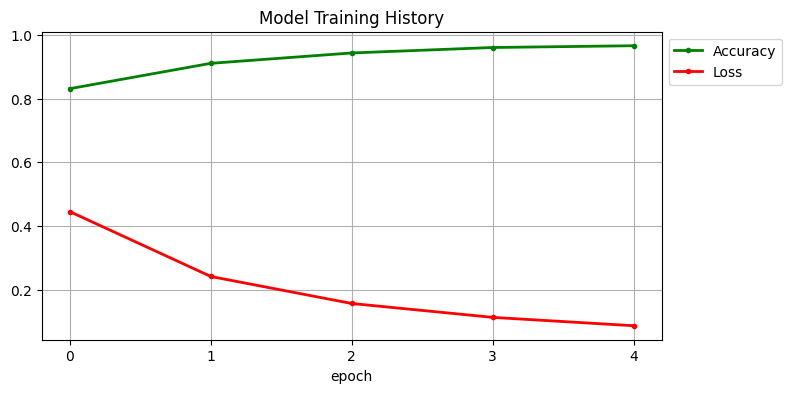

In [ ]:
 # Görselleştirme için grafik boyutları ayarlanıyor
plt.figure(figsize=(8,4))  # Grafiğin boyutu 8x4 inç olarak ayarlanıyor

# Grid (ızgara) ekleniyor
plt.grid(True)  # Grafik üzerine ızgara çizgileri eklenir, böylece okuma daha kolay olur

# Doğruluk (accuracy) grafiği çiziliyor
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)  # Eğitim doğruluğu (.g-: yeşil noktalı çizgi) çiziliyor, çizgi kalınlığı 2 piksel

# Kayıp (loss) grafiği çiziliyor
plt.plot(history.history['loss'], '.r-', linewidth=2)  # Eğitim kaybı (.r-: kırmızı noktalı çizgi) çiziliyor, çizgi kalınlığı 2 piksel

# Başlık ekleniyor
plt.title('Model Training History')  # Grafiğin başlığı

# X eksenine etiket ekleniyor
plt.xlabel('epoch')  # X ekseninin etiketi "epoch" olarak belirleniyor

# X eksenindeki etiketlerin konumu ayarlanıyor
plt.xticks([x for x in range(epochs)])  # X ekseninde 0'dan `epochs`'a kadar olan değerler gösterilecek

# Legend (açıklama) ekleniyor
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))  # "Accuracy" ve "Loss" etiketleri, açıklamayı sağ üst köşeye yerleştirir

# Grafiği göster
plt.show()  # Grafiği görüntüler

In [ ]:
import matplotlib.pyplot as plt  # Grafik çizim kütüphanesi
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc  # Performans ölçüm metrikleri
import seaborn as sns  # Veri görselleştirme kütüphanesi
from sklearn.preprocessing import label_binarize  # Etiketlerin binary formatta dönüştürülmesi
from tensorflow.keras.models import load_model  # Eğitilmiş modelin yüklenmesi
import numpy as np  # Sayısal işlemler için kütüphane

# 1. Test verisi üzerinde tahmin yapma
test_images = open_images(test_paths)  # Test verilerini yükler ve artırır (augmentation uygular)
test_labels_encoded = encode_label(test_labels)  # Test etiketlerini sayısal değerlere dönüştürür

# Eğitilmiş model ile tahmin yapma
test_predictions = model.predict(test_images)

# 2. Sınıflandırma raporunun yazdırılması
print("Classification Report:")
# Gerçek etiketler ile tahmin edilen etiketlerin karşılaştırılması
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

41/41 ━━━━━━━━━━━━━━━━━━━━ 241s 6s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       306
           1       0.97      0.87      0.92       300
           2       0.98      0.99      0.99       300
           3       0.99      0.98      0.98       405

    accuracy                           0.95      1311
   macro avg       0.95      0.95      0.95      1311
weighted avg       0.95      0.95      0.95      1311



Confusion Matrix:
[[292   5   4   5]
 [ 36 262   2   0]
 [  3   0 297   0]
 [  4   4   0 397]]


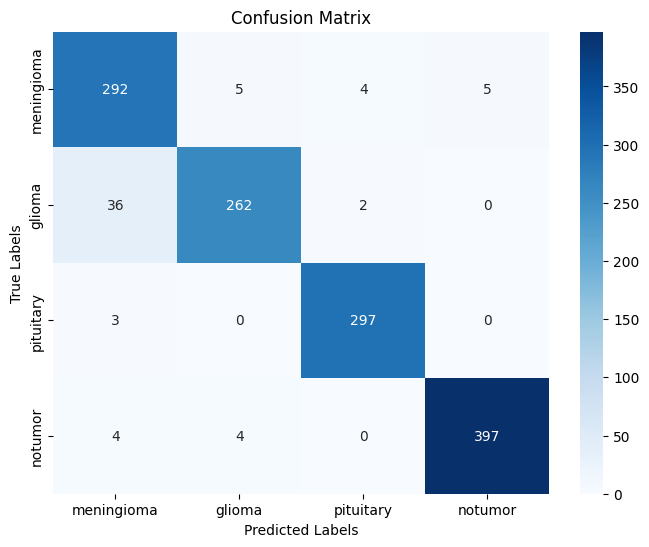

In [ ]:
# 3. Confusion Matrix (Karmaşa Matrisi)
# Confusion matrix, modelin doğru ve yanlış sınıflandırmalarını görselleştiren bir araçtır.
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))  # Gerçek etiketler ve tahmin edilen etiketler arasındaki karşılaştırma
print("Confusion Matrix:")
print(conf_matrix)  # Karmaşa matrisini yazdırma

# Karmaşa matrisini görselleştirme
plt.figure(figsize=(8, 6))  # Grafik boyutunu ayarlama
# `sns.heatmap()` fonksiyonu ile karmaşa matrisini görsel olarak gösterme
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
# Grafiğin başlığını ekleme
plt.title("Confusion Matrix")
# X ve Y eksenlerini etiketleme
plt.xlabel("Predicted Labels")  # Tahmin edilen etiketler
plt.ylabel("True Labels")  # Gerçek etiketler
# Görseli gösterme
plt.show()

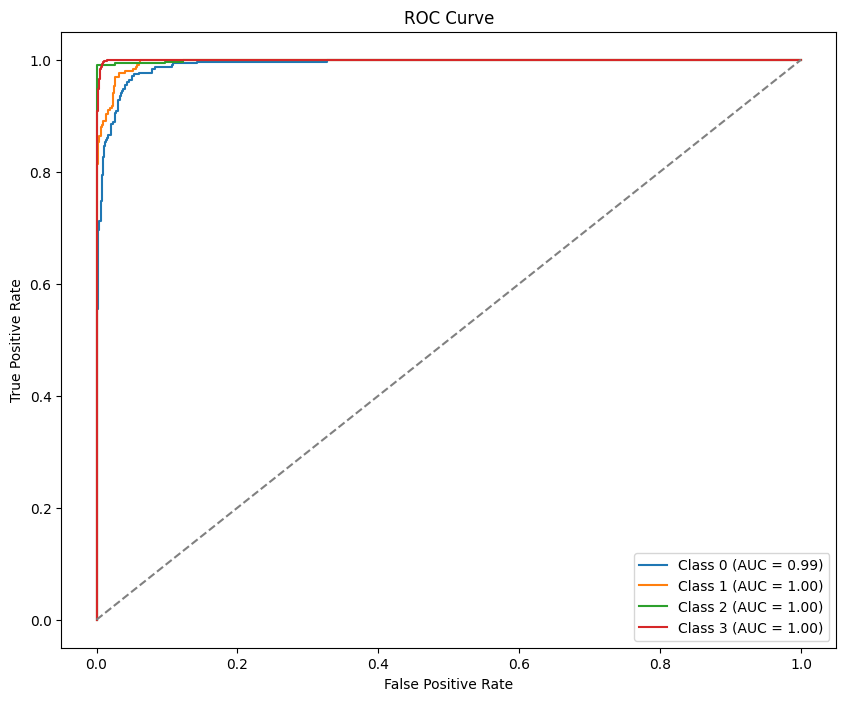

In [ ]:
# 4. ROC Curve and AUC (Receiver Operating Characteristic Curve ve AUC)
# Test etiketlerini ve tahminlerini çok sınıflı ROC için binarize etme
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))  # Gerçek etiketlerin binarize edilmesi
test_predictions_bin = test_predictions  # Her sınıf için tahmin edilen olasılıklar

# Her sınıf için ROC eğrisini ve AUC'yi hesaplama
fpr, tpr, roc_auc = {}, {}, {}  # False Positive Rate (FPR), True Positive Rate (TPR) ve AUC'yi saklayacak sözlükler

# Her sınıf için ROC eğrisini ve AUC'yi hesaplamak
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])  # ROC eğrisini hesaplama
    roc_auc[i] = auc(fpr[i], tpr[i])  # AUC'yi hesaplama

# ROC eğrisini görselleştirme
plt.figure(figsize=(10, 8))  # Grafik boyutunu ayarlama
for i in range(len(os.listdir(train_dir))):  # Her sınıf için ROC eğrisini çizme
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Diyagonal çizgi (rastgele tahmin) ekleme
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diyagonal çizgi

# Başlık ve eksen etiketleri ekleme
plt.title("ROC Curve")  # Başlık
plt.xlabel("False Positive Rate")  # X ekseni etiketi
plt.ylabel("True Positive Rate")  # Y ekseni etiketi

# Legend ekleyerek her sınıfın AUC değerini gösterme
plt.legend(loc="lower right")  # Aşağı sağda gösterilecek şekilde konumlandırma

# Grafiği gösterme
plt.show()


In [ ]:
model.save('model.h5')

In [ ]:
from tensorflow.keras.models import load_model
# Load the trained model
model = load_model('model.h5')

In [ ]:
from keras.preprocessing.image import load_img, img_to_array  # Keras kütüphanesinden görsel işleme fonksiyonları
import numpy as np  # Numpy kütüphanesini dahil ediyoruz
import matplotlib.pyplot as plt  # Görseli görselleştirmek için matplotlib

# Sınıf etiketleri: Modelin tahmin edeceği sınıflar
class_labels = ['pituitary', 'glioma', 'notumor', 'meningioma']  # Sınıflarımız

def detect_and_display(img_path, model, image_size=128):
    """
    Tümör tespiti ve sonucu görselleştirme fonksiyonu.
    Eğer tümör tespit edilmezse "No Tumor" mesajı gösterir.
    Aksi halde, tahmin edilen tümör türü ve güven skorunu gösterir.
    """
    try:
        # Görseli yükleme ve ön işleme
        img = load_img(img_path, target_size=(image_size, image_size))  # Görseli belirtilen boyutta yükle
        img_array = img_to_array(img) / 255.0  # Görselin piksel değerlerini normalize et (0-255 yerine 0-1 aralığına)
        img_array = np.expand_dims(img_array, axis=0)  # Batch boyutunu ekle, çünkü model batch girişini bekler

        # Model ile tahmin yapma
        predictions = model.predict(img_array)  # Görsel üzerinde tahmin yap
        predicted_class_index = np.argmax(predictions, axis=1)[0]  # Tahmin edilen sınıfın indeksini al
        confidence_score = np.max(predictions, axis=1)[0]  # En yüksek olasılık değerini al

        # Sonucu belirleme
        if class_labels[predicted_class_index] == 'notumor':  # Eğer tahmin edilen sınıf "notumor" ise
            result = "No Tumor"  # "No Tumor" sonucu göster
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"  # Aksi takdirde, tümörün türünü belirt

        # Görseli ve tahmini sonuçları ekrana yazdırma
        plt.imshow(load_img(img_path))  # Görseli yükle ve göster
        plt.axis('off')  # Eksenleri gizle
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")  # Başlığa tahmini sonucu ve güven skorunu ekle
        plt.show()  # Görseli göster

    except Exception as e:
        # Eğer bir hata olursa, hata mesajını yazdır
        print("Hata oluştu:", str(e))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step


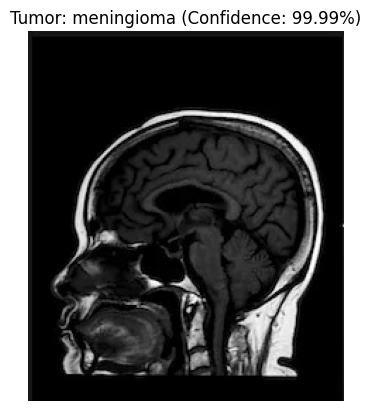

In [ ]:
# Örnek kullanım
image_path = '/content/drive/MyDrive/Te-noTr_0004.jpg'  # Yeni görselin yolu
detect_and_display(image_path, model)  # Görseli tahmin et ve sonucu göster


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step


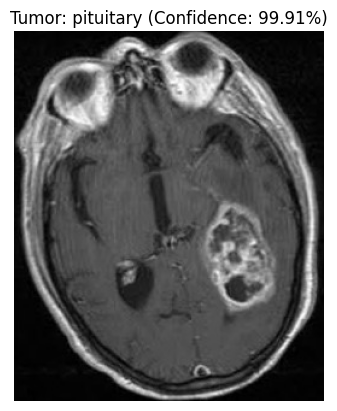

In [ ]:
image_path = '/content/drive/MyDrive/Te-meTr_0001.jpg'  # Yeni görselin yolu
detect_and_display(image_path, model)  # Görseli tahmin et ve sonucu göster


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step


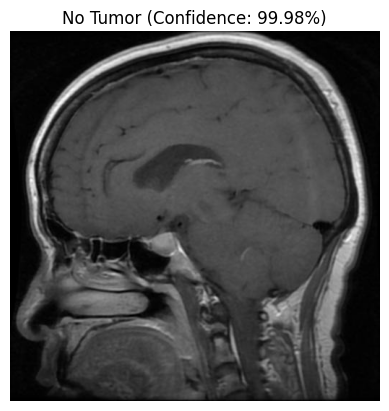

In [ ]:
# Example usage
image_path = '/content/drive/MyDrive/Te-piTr_0003.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step


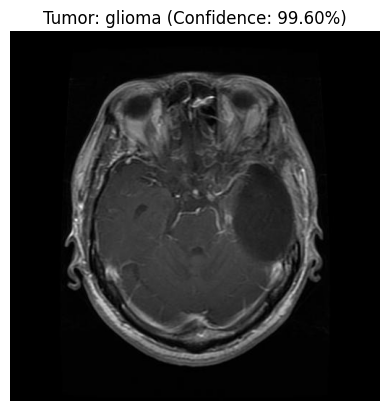

In [ ]:
#Example usage
image_path = '/content/drive/MyDrive/Te-gl_0015.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)